In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import ast

In [59]:
def accuracies(tab):
    tab.reset_index(inplace=True)
    tab["skip_config"] = tab.apply(lambda row: f"Encoder: {row['model']}, Dataset: {row['dataset']}, Block: {row['approx_layer']}, Block Mode: {row['translator']}, MLP: {row['mlp_linearize']}, MLP Mode: {row['mlp_mode']}, Attn: {row['attn_linearize']} Heads: {row['head_dict']}", axis=1)
    accuracies = tab[["skip_config", "seed", "accuracy","index"]].groupby(["skip_config"]).agg({"accuracy": ["mean", "std"], "index": ["first"]}).reset_index().sort_values(by=("index", "first"), ascending=True)
    accuracies.columns = ["skip_config", "accuracy_mean", "accuracy_std", "order"]
    new_df = pd.merge(tab, accuracies, on="skip_config", how="left")
    new_df = new_df[["skip_config", "model", "dataset", "approx_layer", "translator", "mlp_linearize", "mlp_mode", "attn_linearize", "head_dict", "accuracy_mean", "accuracy_std"]]
    new_df.drop_duplicates(inplace=True)
    new_df.sort_values(by=["model", "accuracy_mean"], ascending=[True, False], inplace=True)
    return new_df

df = pd.read_csv("results_skip_grid.csv")
accuracies_df = accuracies(df)

In [60]:
accuracies_df["approx_layer"] = accuracies_df["approx_layer"].apply(lambda x: ast.literal_eval(x))
accuracies_df["skip_distance"] = accuracies_df.apply(lambda row: row["approx_layer"][1][0] - row["approx_layer"][0][0] if len(row["approx_layer"]) > 1 else len(row["approx_layer"]), axis=1)
accuracies_df["skip_count"] = accuracies_df.apply(lambda row: 2 if len(row["approx_layer"]) > 1 else 0 if len(row["approx_layer"]) == 0 else row["approx_layer"][0][1] - row["approx_layer"][0][0], axis=1)
accuracies_df["first_skip"] = accuracies_df.apply(lambda row: row["approx_layer"][0][0] if len(row["approx_layer"]) > 0 else -1, axis=1)
accuracies_df["translator"] = accuracies_df.apply(lambda row: row["translator"] if row["translator"] != "None" else "Identity", axis=1)
accuracies_df["approx_layer_str"] = accuracies_df["approx_layer"].apply(lambda x: str(x))
accuracies_df.sort_values(by=["first_skip", "skip_count", "skip_distance", "translator"], ascending=[True, True, True, True], inplace=True)

In [61]:
accuracies_df

,skip_config,model,dataset,approx_layer,translator,mlp_linearize,mlp_mode,attn_linearize,head_dict,accuracy_mean,accuracy_std,skip_distance,skip_count,first_skip,approx_layer_str
2412,"Encoder: facebook/deit-base-patch16-224, Datas...",facebook/deit-base-patch16-224,pneumoniamnist,[],identity,[],identity,[],{},0.819444,0.016680,0,0,-1,[]
1884,"Encoder: facebook/deit-base-patch16-224, Datas...",facebook/deit-base-patch16-224,imagenet-1k,[],identity,[],identity,[],{},0.776200,0.002265,0,0,-1,[]
2148,"Encoder: facebook/deit-base-patch16-224, Datas...",facebook/deit-base-patch16-224,cifar100,[],identity,[],identity,[],{},0.755467,0.001662,0,0,-1,[]
816,"Encoder: facebook/deit-base-patch16-224, Datas...",facebook/deit-base-patch16-224,dermamnist,[],identity,[],identity,[],{},0.740482,0.001888,0,0,-1,[]
2808,"Encoder: facebook/deit-small-patch16-224, Data...",facebook/deit-small-patch16-224,pneumoniamnist,[],identity,[],identity,[],{},0.785791,0.008826,0,0,-1,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1149,"Encoder: google/vit-large-patch16-224, Dataset...",google/vit-large-patch16-224,dermamnist,"[(22, 23)]",identity,[],identity,[],{},0.756276,0.008814,1,1,22,"[(22, 23)]"
207,"Encoder: google/vit-large-patch16-224, Dataset...",google/vit-large-patch16-224,cifar100,"[(22, 23)]",linear,[],identity,[],{},0.865167,0.001704,1,1,22,"[(22, 23)]"
747,"Encoder: google/vit-large-patch16-224, Dataset...",google/vit-large-patch16-224,pneumoniamnist,"[(22, 23)]",linear,[],identity,[],{},0.829594,0.021876,1,1,22,"[(22, 23)]"
4506,"Encoder: google/vit-large-patch16-224, Dataset...",google/vit-large-patch16-224,imagenet-1k,"[(22, 23)]",linear,[],identity,[],{},0.783633,0.003522,1,1,22,"[(22, 23)]"


In [62]:
analysis_csv = accuracies_df[["model", "dataset", "approx_layer_str", "translator", "accuracy_mean", "accuracy_std", "skip_distance", "skip_count", "first_skip"]]
linear_analysis_csv = analysis_csv[analysis_csv["translator"] == "linear"]
identity_analysis_csv = analysis_csv[analysis_csv["translator"] == "identity"]
accuracies_df = pd.merge(linear_analysis_csv, identity_analysis_csv, on=["model", "dataset", "approx_layer_str", "skip_distance", "skip_count", "first_skip"], suffixes=("_linear", "_identity"))
accuracies_df.sort_values(by=["skip_count", "skip_distance", "first_skip"], ascending=[True, True, True], inplace=True)
accuracies_df.to_csv("distance_analysis.csv", index=False)
#analysis_csv.to_csv("distance_analysis.csv", index=False)

Model: facebook/deit-base-patch16-224, Dataset: pneumoniamnist, Number of configurations: 22


/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_18027/3166112148.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_dataset_df.sort_values(by=["first_skip", "skip_count", "skip_distance"], ascending=[True, True, True], inplace=True)
/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_18027/3166112148.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accuracies_df_skip.sort_values(by=["first_skip"], ascending=[True], inplace=True)


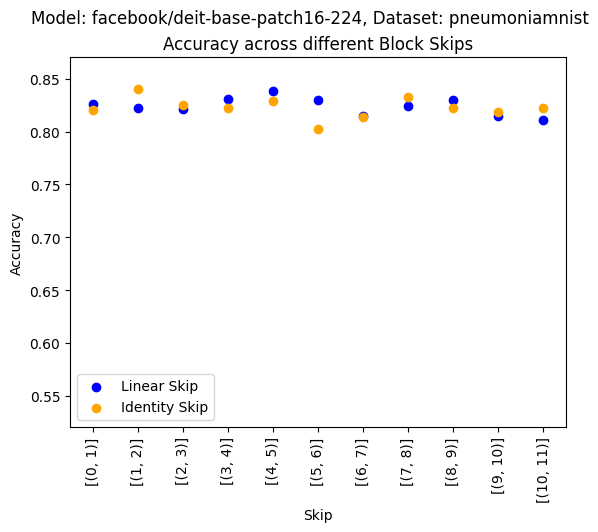

Model: facebook/deit-base-patch16-224, Dataset: imagenet-1k, Number of configurations: 22


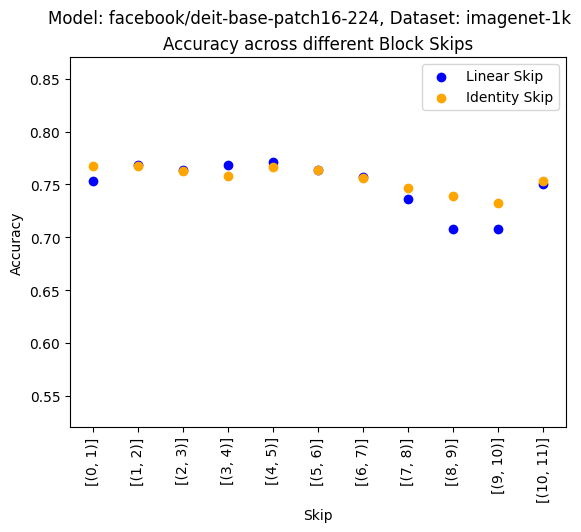

Model: facebook/deit-base-patch16-224, Dataset: cifar100, Number of configurations: 22


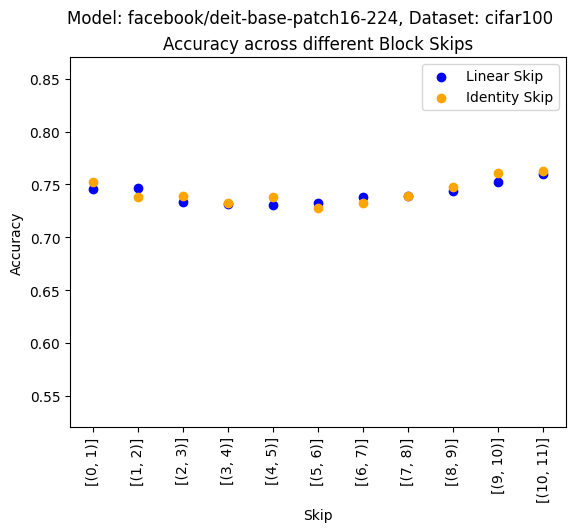

Model: facebook/deit-base-patch16-224, Dataset: dermamnist, Number of configurations: 22


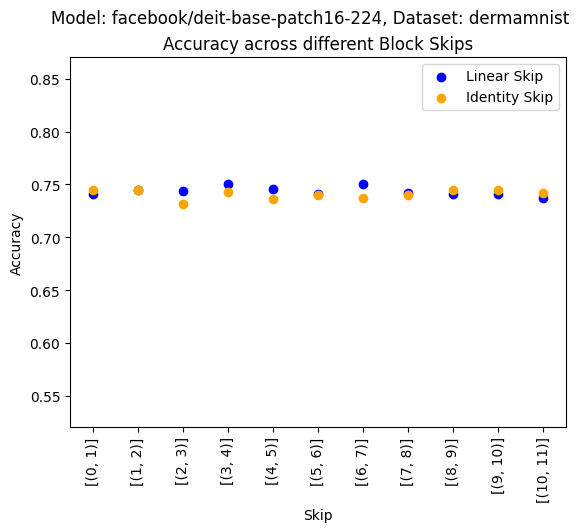

Model: facebook/deit-small-patch16-224, Dataset: pneumoniamnist, Number of configurations: 22


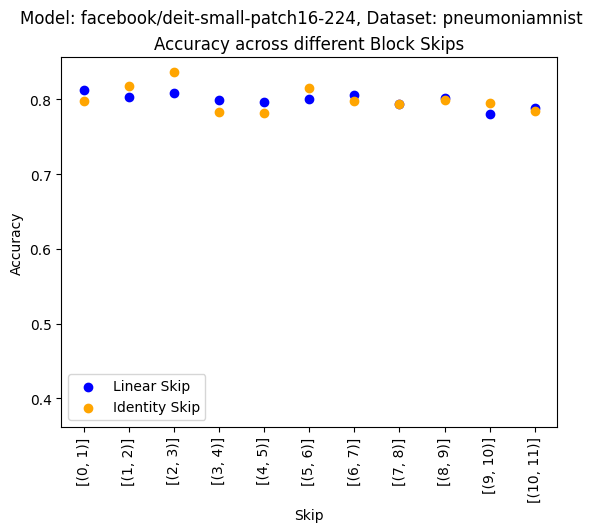

Model: facebook/deit-small-patch16-224, Dataset: imagenet-1k, Number of configurations: 67


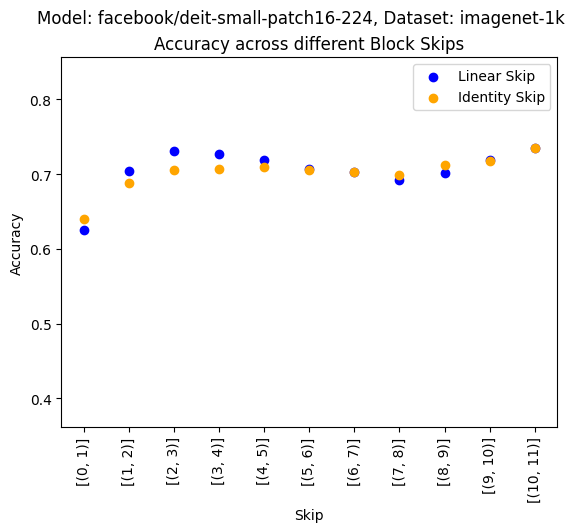

Model: facebook/deit-small-patch16-224, Dataset: cifar100, Number of configurations: 22


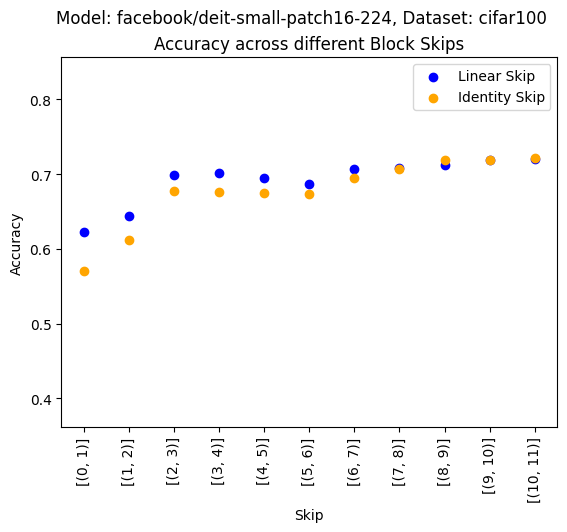

Model: facebook/deit-small-patch16-224, Dataset: dermamnist, Number of configurations: 22


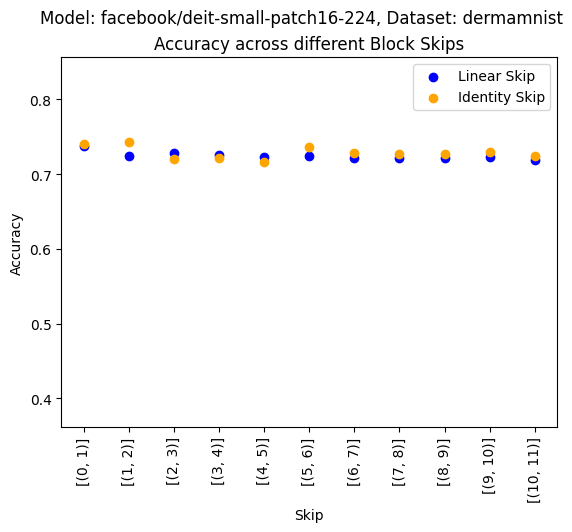

Model: facebook/dinov2-base, Dataset: pneumoniamnist, Number of configurations: 22


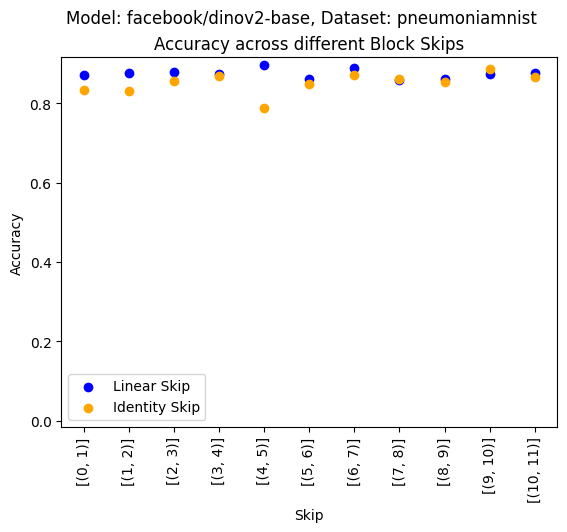

Model: facebook/dinov2-base, Dataset: imagenet-1k, Number of configurations: 67


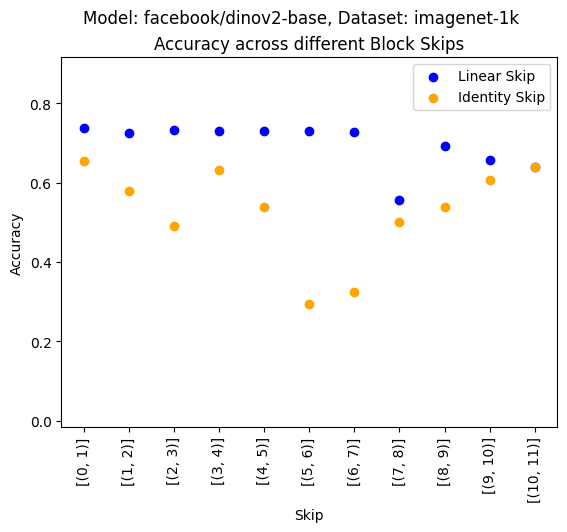

Model: facebook/dinov2-base, Dataset: cifar100, Number of configurations: 22


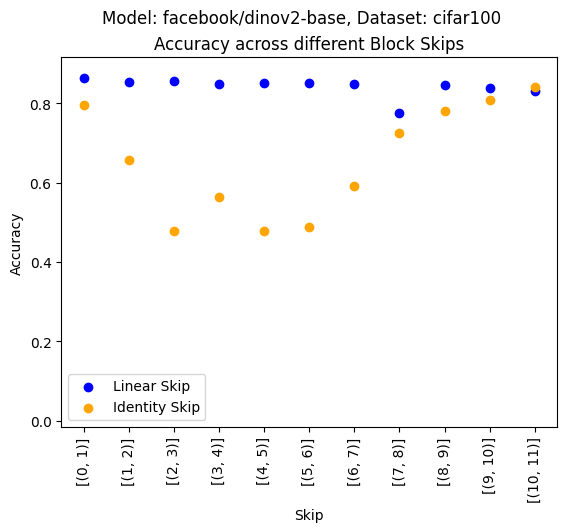

Model: facebook/dinov2-base, Dataset: dermamnist, Number of configurations: 22


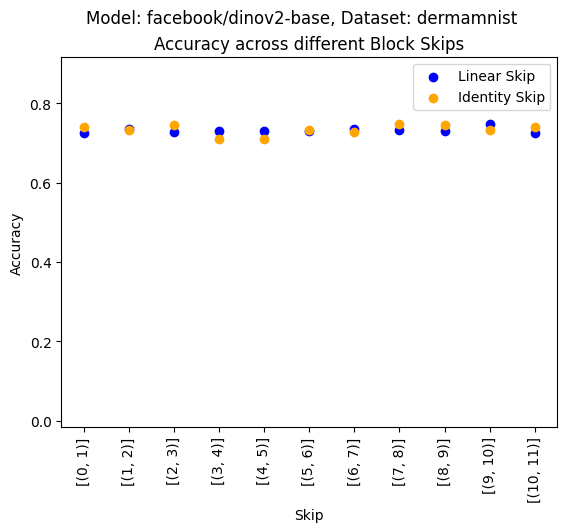

Model: google/vit-base-patch16-224, Dataset: pneumoniamnist, Number of configurations: 22


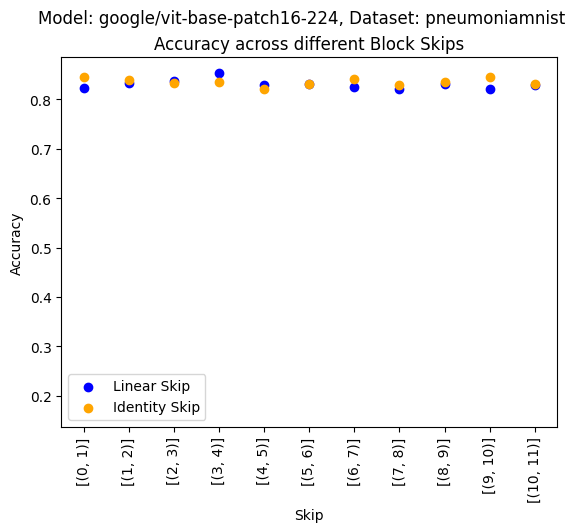

Model: google/vit-base-patch16-224, Dataset: imagenet-1k, Number of configurations: 22


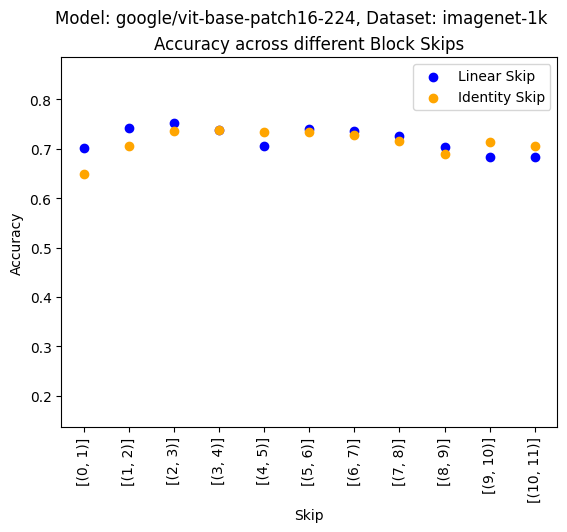

Model: google/vit-base-patch16-224, Dataset: cifar100, Number of configurations: 22


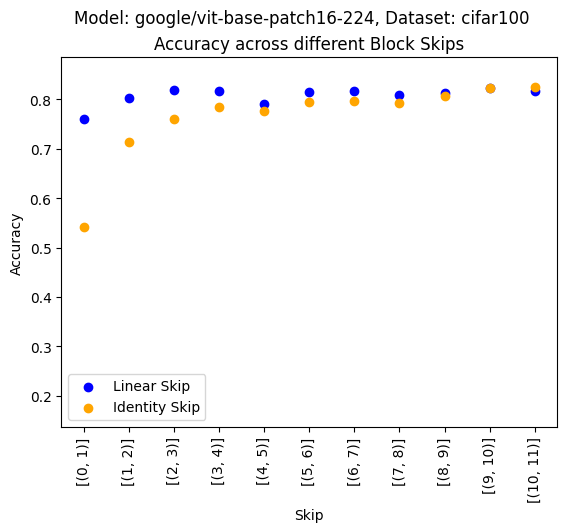

Model: google/vit-base-patch16-224, Dataset: dermamnist, Number of configurations: 22


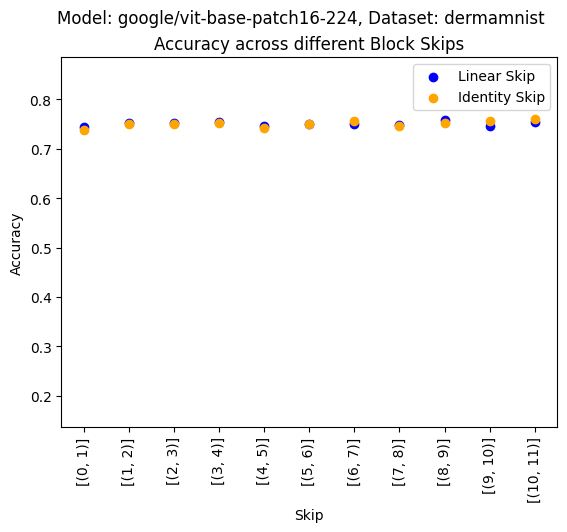

Model: google/vit-large-patch16-224, Dataset: pneumoniamnist, Number of configurations: 46


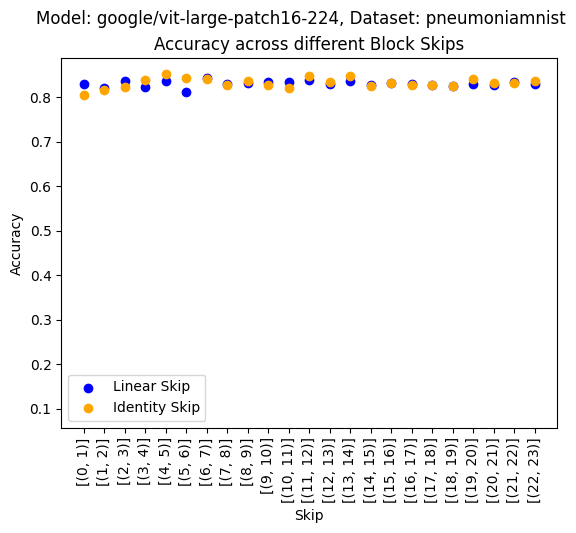

Model: google/vit-large-patch16-224, Dataset: imagenet-1k, Number of configurations: 232


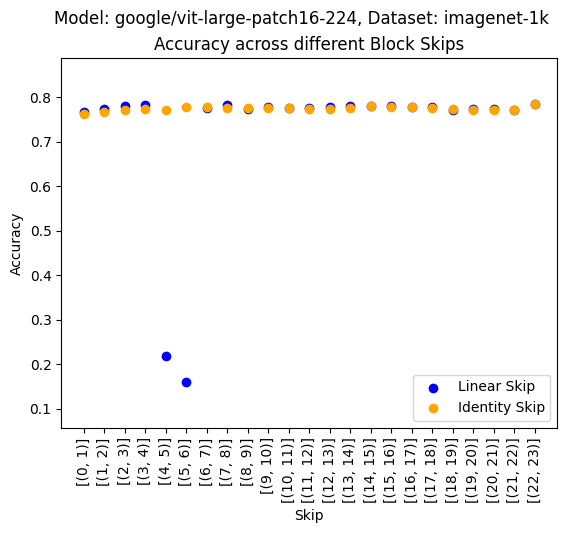

Model: google/vit-large-patch16-224, Dataset: cifar100, Number of configurations: 46


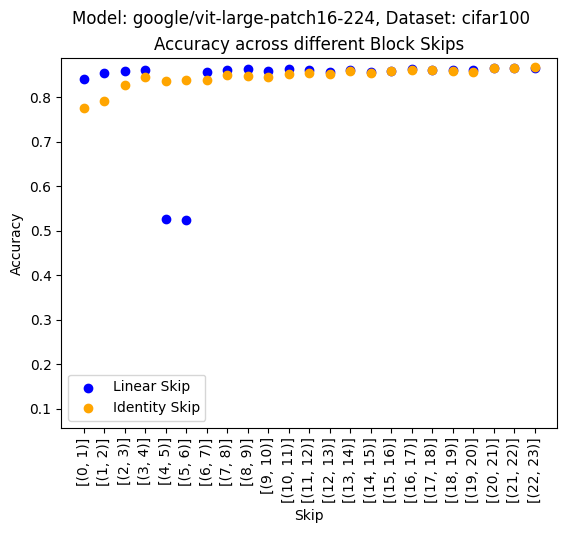

Model: google/vit-large-patch16-224, Dataset: dermamnist, Number of configurations: 46


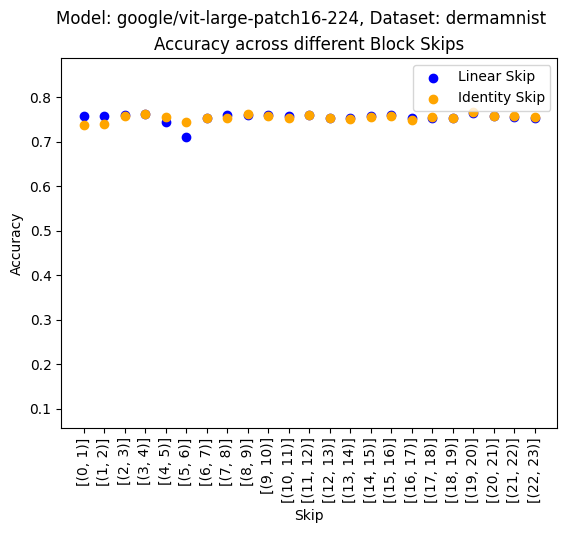

Model: microsoft/rad-dino, Dataset: pneumoniamnist, Number of configurations: 22


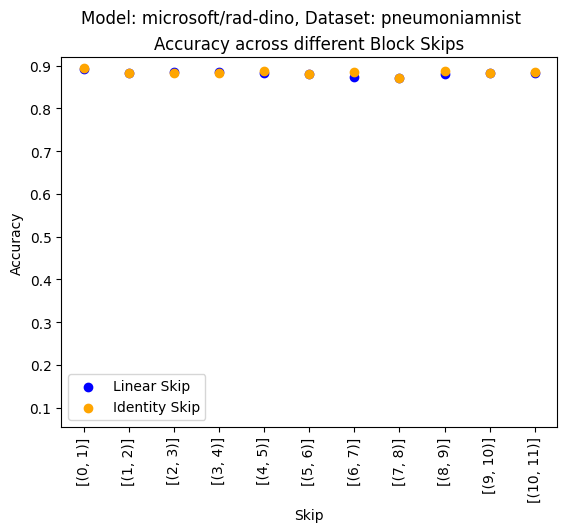

Model: microsoft/rad-dino, Dataset: imagenet-1k, Number of configurations: 22


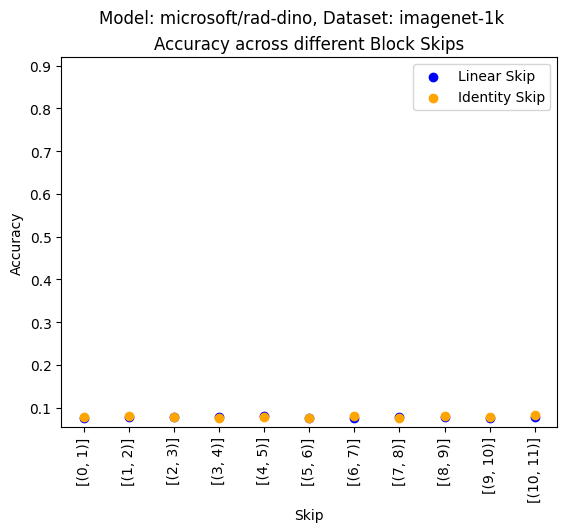

Model: microsoft/rad-dino, Dataset: cifar100, Number of configurations: 22


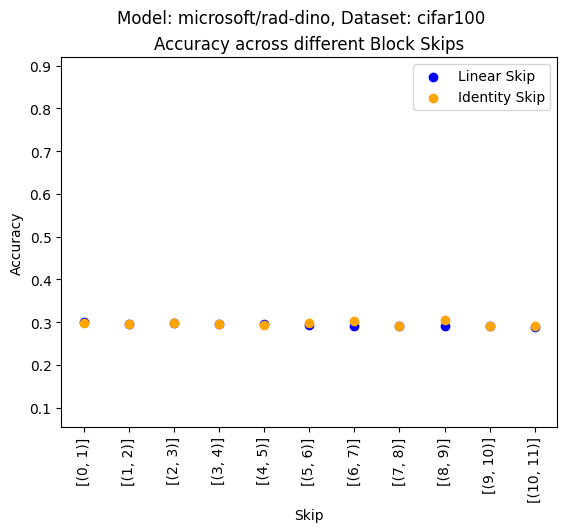

Model: microsoft/rad-dino, Dataset: dermamnist, Number of configurations: 22


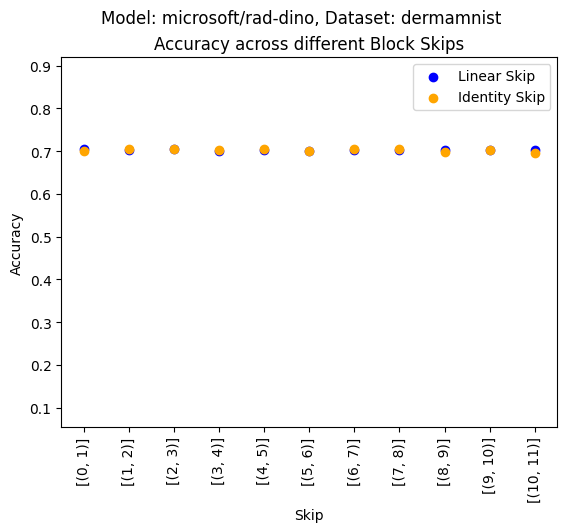

In [71]:
import os

for model in accuracies_df["model"].unique():
    model_dataset_df = accuracies_df[accuracies_df["model"] == model]
    best_val_linear = model_dataset_df['accuracy_mean_linear'].max()
    best_val_identity = model_dataset_df['accuracy_mean_identity'].max()
    worst_val_linear = model_dataset_df['accuracy_mean_linear'].min()
    worst_val_identity = model_dataset_df['accuracy_mean_identity'].min()
    best_val = max(best_val_linear, best_val_identity) + 0.02
    worst_val = min(worst_val_linear, worst_val_identity) - 0.02
    for dataset in accuracies_df["dataset"].unique():
        model_dataset_df = accuracies_df[(accuracies_df["model"] == model) & (accuracies_df["dataset"] == dataset)]
        print(f"Model: {model}, Dataset: {dataset}, Number of configurations: {len(model_dataset_df)}")
        if not model_dataset_df.empty:
            # gets max/mins for plotting format

            model_dataset_df.sort_values(by=["first_skip", "skip_count", "skip_distance"], ascending=[True, True, True], inplace=True)
            accuracies_df_skip = model_dataset_df[model_dataset_df["skip_count"] == 1]
            accuracies_df_skip.sort_values(by=["first_skip"], ascending=[True], inplace=True)
            plt.title(f"Accuracy across different Block Skips")
            plt.suptitle(f"Model: {model}, Dataset: {dataset}")
            plt.scatter(accuracies_df_skip["approx_layer_str"], accuracies_df_skip["accuracy_mean_linear"], color="blue", label=f"Linear Skip")
            plt.scatter(accuracies_df_skip["approx_layer_str"], accuracies_df_skip["accuracy_mean_identity"], color="orange", label=f"Identity Skip")
            plt.xlabel("Skip")
            plt.ylim(worst_val, best_val)
            plt.xticks(rotation=90)
            plt.ylabel("Accuracy")
            plt.legend()
            os.makedirs("plots", exist_ok=True)
            model_str = model.replace("/", "_")
            dataset_str = dataset.replace("/", "_")
            plt.savefig(f"plots/{model_str}_{dataset_str}_distance_analysis_single_block.png", bbox_inches="tight")
            plt.show()
            plt.close()

In [ ]:
# model x dataset subplot grid:
# x-axis = skip distance, y-axis = accuracy, with one line for linear and one for identity

models = accuracies_df["model"].unique()
datasets = accuracies_df["dataset"].unique()

fig, axs = plt.subplots(
    len(models),
    len(datasets),
    figsize=(4 * len(datasets), 3 * len(models)),
    sharex=True,
    sharey=True,
    squeeze=False
)

for model_idx, model in enumerate(models):
    for dataset_idx, dataset in enumerate(datasets):
        ax = axs[model_idx, dataset_idx]
        model_dataset_df = accuracies_df[
            (accuracies_df["model"] == model) & (accuracies_df["dataset"] == dataset)
        ].copy()

        if model_dataset_df.empty:
            ax.set_title(f"{model}\n{dataset}\n(no data)")
            continue

        # aggregate by skip distance so each line is distance -> mean accuracy
        by_dist = model_dataset_df.groupby("skip_distance", as_index=False).agg(
            accuracy_mean_linear=("accuracy_mean_linear", "mean"),
            accuracy_mean_identity=("accuracy_mean_identity", "mean")
        ).sort_values("skip_distance")

        ax.plot(
            by_dist["skip_distance"],
            by_dist["accuracy_mean_linear"],
            marker="o",
            color="blue",
            label="Linear Skip"
        )
        ax.plot(
            by_dist["skip_distance"],
            by_dist["accuracy_mean_identity"],
            marker="o",
            color="orange",
            label="Identity Skip"
        )

        ax.set_title(f"{model}\n{dataset}")
        ax.set_xlabel("Skip Distance")
        ax.set_ylabel("Accuracy")
        ax.grid(alpha=0.3)

# one shared legend
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

os.makedirs("plots", exist_ok=True)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("plots/overall_distance_analysis.png", bbox_inches="tight")
plt.show()
plt.close(fig)

Model: facebook/deit-base-patch16-224, Dataset: pneumoniamnist, Number of configurations: 22


/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_18027/2432158655.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_dataset_df.sort_values(by=["first_skip", "skip_count", "skip_distance"], ascending=[True, True, True], inplace=True)
/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_18027/2432158655.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accuracies_df_skip.sort_values(by=["first_skip"], ascending=[True], inplace=True)


Model: facebook/deit-base-patch16-224, Dataset: imagenet-1k, Number of configurations: 22
Model: facebook/deit-base-patch16-224, Dataset: cifar100, Number of configurations: 22
Model: facebook/deit-base-patch16-224, Dataset: dermamnist, Number of configurations: 22
Model: facebook/deit-small-patch16-224, Dataset: pneumoniamnist, Number of configurations: 22
Model: facebook/deit-small-patch16-224, Dataset: imagenet-1k, Number of configurations: 67
Model: facebook/deit-small-patch16-224, Dataset: cifar100, Number of configurations: 22
Model: facebook/deit-small-patch16-224, Dataset: dermamnist, Number of configurations: 22
Model: facebook/dinov2-base, Dataset: pneumoniamnist, Number of configurations: 22
Model: facebook/dinov2-base, Dataset: imagenet-1k, Number of configurations: 67
Model: facebook/dinov2-base, Dataset: cifar100, Number of configurations: 22
Model: facebook/dinov2-base, Dataset: dermamnist, Number of configurations: 22
Model: google/vit-base-patch16-224, Dataset: pneumon

In [64]:
best_val_linear = accuracies_df['accuracy_mean_linear'].max()
best_val_identity = accuracies_df['accuracy_mean_identity'].max()
worst_val_linear = accuracies_df['accuracy_mean_linear'].min()
worst_val_identity = accuracies_df['accuracy_mean_identity'].min()
best_val = max(best_val_linear, best_val_identity) + 0.02
worst_val = min(worst_val_linear, worst_val_identity) - 0.02

In [65]:
accuracies_df.sort_values(by=["first_skip", "skip_count", "skip_distance"], ascending=[True, True, True], inplace=True)

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_18027/3509079353.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accuracies_df_skip.sort_values(by=["first_skip"], ascending=[True], inplace=True)


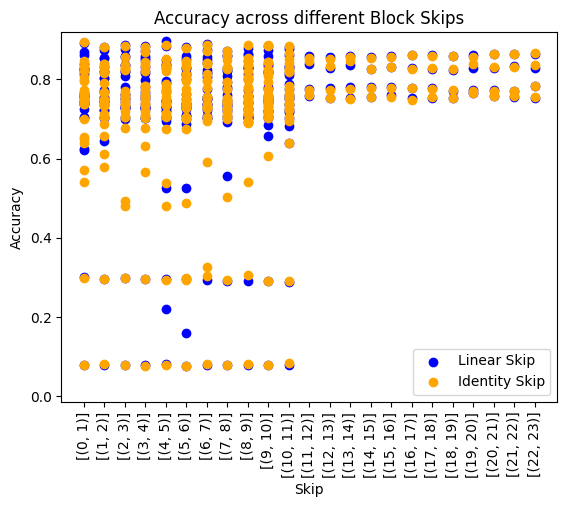

In [66]:
accuracies_df_skip = accuracies_df[accuracies_df["skip_count"] == 1]
accuracies_df_skip.sort_values(by=["first_skip"], ascending=[True], inplace=True)
plt.title(f"Accuracy across different Block Skips")
plt.scatter(accuracies_df_skip["approx_layer_str"], accuracies_df_skip["accuracy_mean_linear"], color="blue", label=f"Linear Skip")
plt.scatter(accuracies_df_skip["approx_layer_str"], accuracies_df_skip["accuracy_mean_identity"], color="orange", label=f"Identity Skip")
plt.xlabel("Skip")
plt.ylim(worst_val, best_val)
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("distance_analysis.png", bbox_inches="tight")

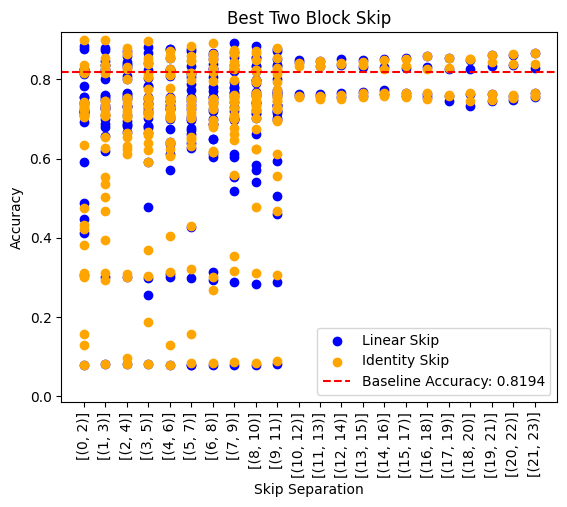

In [67]:
best = accuracies_df["accuracy_mean_linear"].loc[0]
accuracies_df_skip = accuracies_df[accuracies_df["skip_count"] == 2]
accuracies_df_skip = accuracies_df_skip[accuracies_df_skip["skip_distance"] == 1]
accuracies_df_skip.sort_values(by=["first_skip"], ascending=[True], inplace=True)
plt.title(f"Best Two Block Skip")
plt.scatter(accuracies_df_skip["approx_layer_str"], accuracies_df_skip["accuracy_mean_linear"], color="blue", label=f"Linear Skip")
plt.scatter(accuracies_df_skip["approx_layer_str"], accuracies_df_skip["accuracy_mean_identity"], color="orange", label=f"Identity Skip")
plt.xlabel("Skip Separation")
plt.xticks(rotation=90)
plt.ylim(worst_val, best_val)
plt.ylabel("Accuracy")
plt.axhline(y=best, color="red", linestyle="--", label=f"Baseline Accuracy: {best:.4f}")
plt.legend()
plt.show()

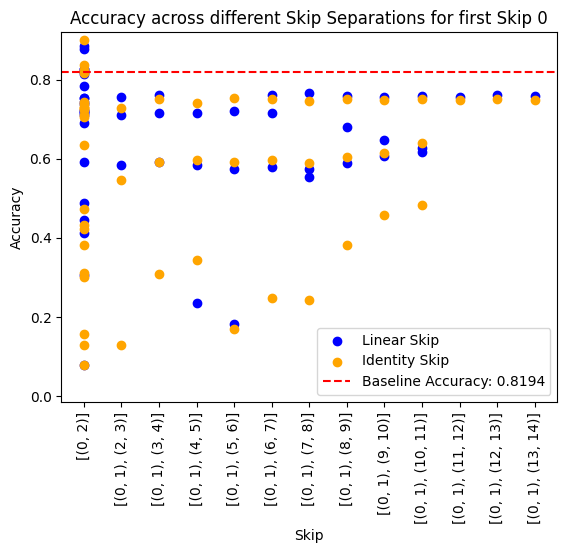

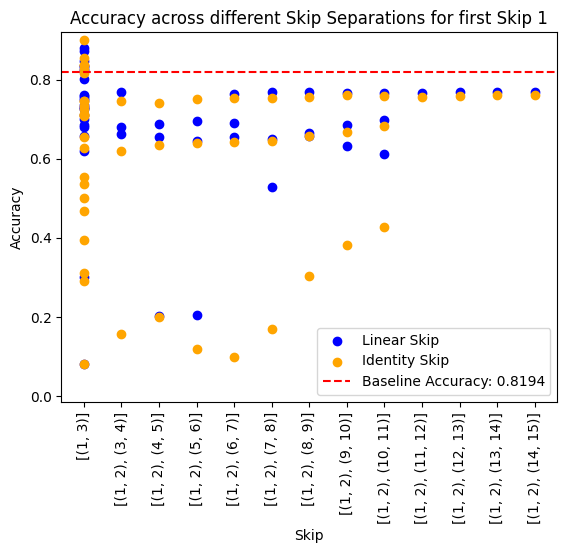

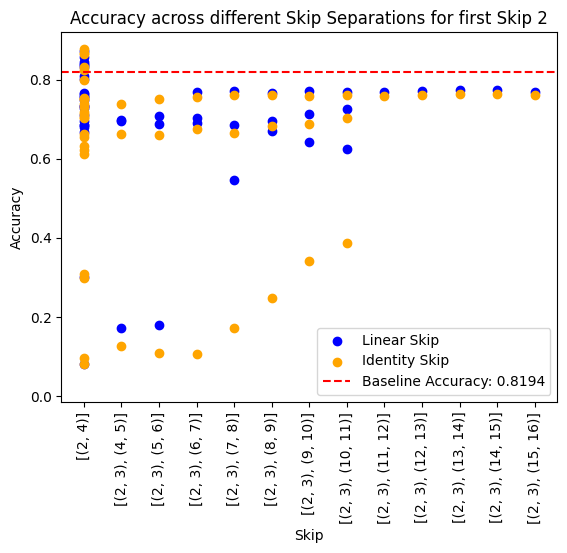

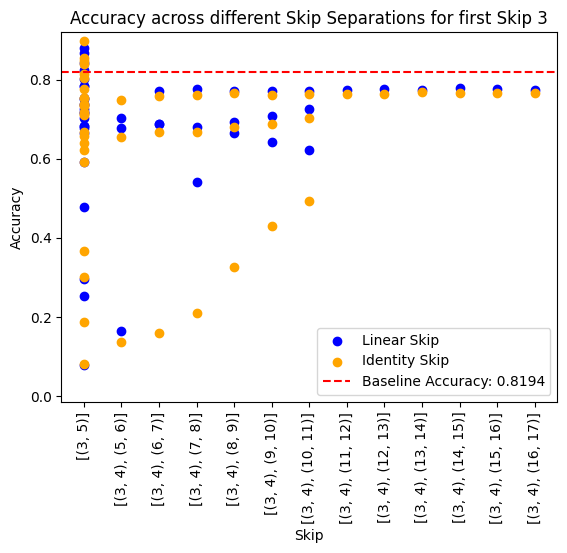

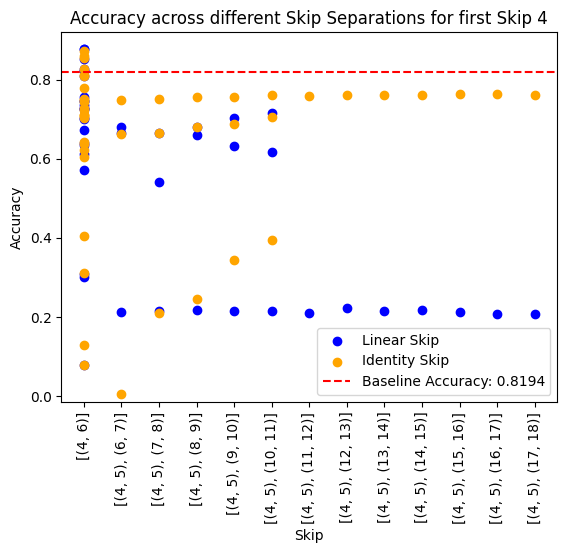

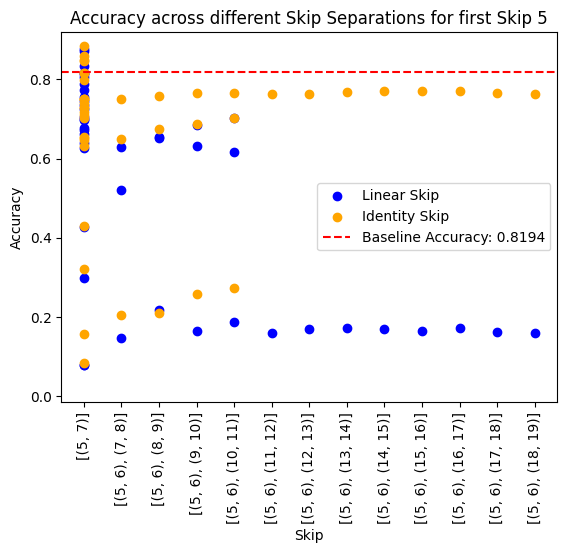

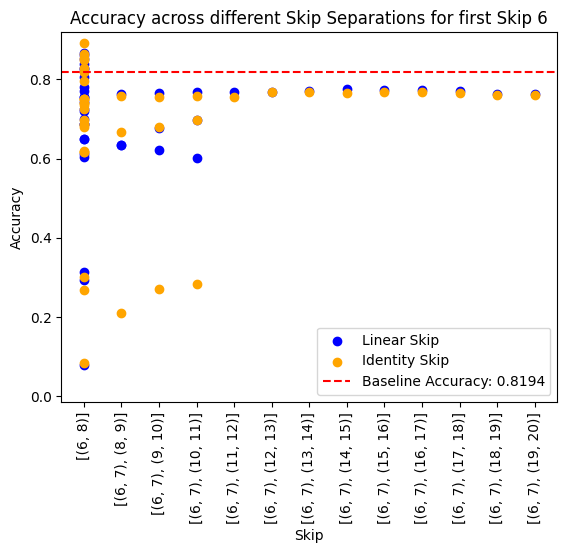

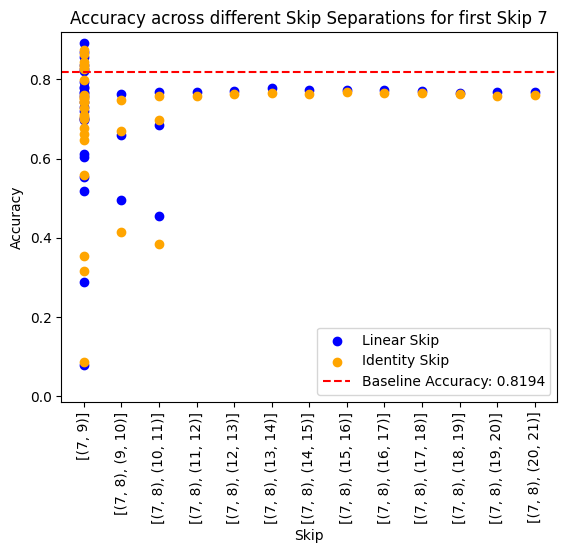

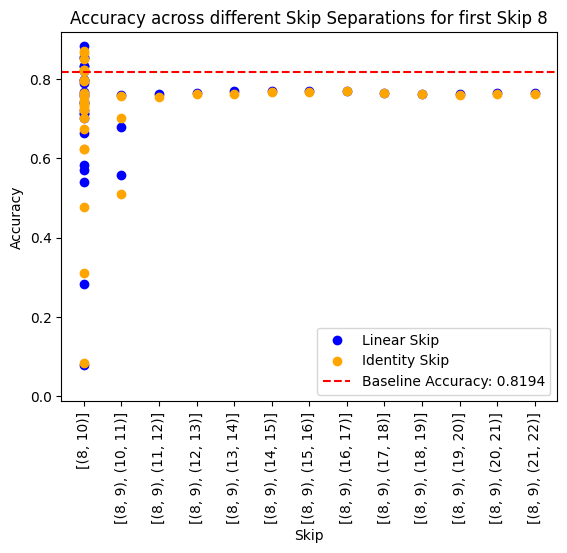

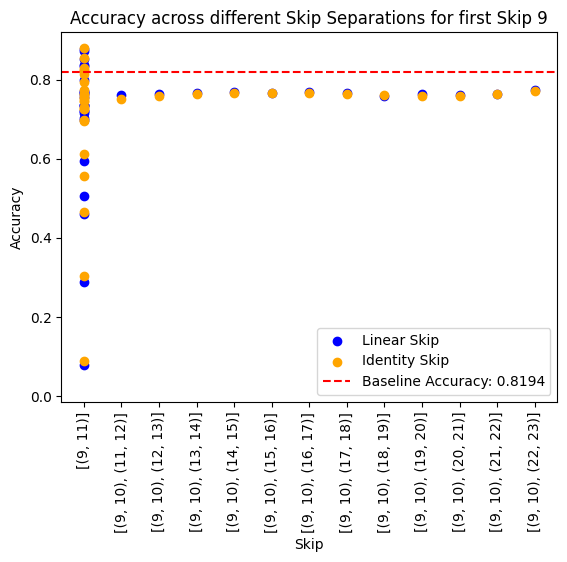

In [68]:
best = accuracies_df["accuracy_mean_linear"].loc[0]
for first_skip in range(0, 10):
    accuracies_df_skip= accuracies_df[accuracies_df["first_skip"] == first_skip]
    accuracies_df_skip = accuracies_df_skip[accuracies_df_skip["skip_count"] > 1]
    accuracies_df_skip.sort_values(by=["skip_distance"], ascending=[True], inplace=True)
    plt.title(f"Accuracy across different Skip Separations for first Skip {first_skip}")
    plt.scatter(accuracies_df_skip["approx_layer_str"], accuracies_df_skip["accuracy_mean_linear"], color="blue", label=f"Linear Skip")
    plt.scatter(accuracies_df_skip["approx_layer_str"], accuracies_df_skip["accuracy_mean_identity"], color="orange", label=f"Identity Skip")
    plt.xlabel("Skip")
    plt.axhline(y=best, color="red", linestyle="--", label=f"Baseline Accuracy: {best:.4f}")
    plt.xticks(rotation=90)
    plt.ylim(worst_val, best_val)
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()